In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [24]:
def dB_to_lin(x):
    return 10**(x/10)

def lin_to_dB(x):
    assert x != 0, "X is zero"
    return 10*np.log10(x)

def plot_3d_state_trajectory(fig, X, legend='$\\mathbf{x}^{true}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    if X.shape[-1] == 2:
        #fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(X[:,0], X[:,1], m, label=legend)
        ax.set_xlabel('$X_1$')
        ax.set_ylabel('$X_2$')
        plt.legend()
        
    elif X.shape[-1] > 2:
        #fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(X[:,0], X[:,1], X[:,2], m)#, label=legend)
        ax.set_xlabel('$X_1$')
        ax.set_ylabel('$X_2$')
        ax.set_zlabel('$X_3$')
        #plt.legend()
        plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

def plot_state_trajectory_axeswise(X, legend='$\\mathbf{x}^{true}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    
    fig = plt.figure()
    ax = fig.add_subplot(311)
    ax.plot(X[:,0], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_1$')
    ax = fig.add_subplot(312)
    ax.plot(X[:,1], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_2$')
    ax = fig.add_subplot(313)
    ax.plot(X[:,2], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_3$')
    #plt.legend()
    #plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

def plot_3d_measurment_trajectory(Y, legend='$\\mathbf{y}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    if Y.shape[-1] == 2:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(Y[:,0], Y[:,1], m, label=legend)
        ax.set_xlabel('$Y_1$')
        ax.set_ylabel('$Y_2$')
        plt.legend()
        
    elif Y.shape[-1] > 2:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        #ax.set_box_aspect((np.ptp(Y[:,0]), np.ptp(Y[:,1]), np.ptp(Y[:,2])))
        #ax.set_box_aspect((1, 1, 1))
        ax.plot(Y[:,0], Y[:,1], Y[:,2], m)#, label=legend)
        ax.set_xlabel('$Y_1$')
        ax.set_ylabel('$Y_2$')
        ax.set_zlabel('$Y_3$')
        #ax.axes.set_zlim3d([0, 60])
        #ax.set_ylim3d([-25, 50])
        #ax.axes.set_zlim3d([0, 50])
        #ax.set_ylim([ymin, ymax])
        #plt.legend()
        plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

class RosslerSSM(object):

    def __init__(self, n_states, n_obs, J, delta, delta_d, a=0.1, b=0.1, c=14.0, decimate=False, K=None, mu_e=None, mu_w=None, H=None, use_Taylor=True) -> None:
        
        self.n_states = n_states
        self.J = J
        self.delta = delta
        self.a = a
        self.b = b
        self.c = c
        self.delta_d = delta_d
        self.n_obs = n_obs
        self.decimate = decimate
        self.K = K
        self.mu_e = mu_e
        if H is None:
            self.H = np.eye(self.n_obs)
        else:
            self.H = H
        self.mu_w = mu_w
        self.use_Taylor = use_Taylor
    
    def A_fn(self, z): 
        return np.array([
        [0, -1, -1],
        [1, self.a, 0],
        [0, 0, (self.b / z[2]) + (z[0] - self.c)]
    ])
    
    #def A_fn(self, z):
    #    return np.array([
    #                [-10, 10, 0],
    #                [28, -1, -z],
    #                [0, z, -8.0/3]
    #            ])
    
    def h_fn(self, x):
        """ 
        Linear measurement setup y = x + w
        """
        if type(x).__module__ == np.__name__:
            H_ = np.copy(self.H)
        elif type(x).__module__ == torch.__name__:
            H_ = torch.from_numpy(self.H).type(torch.FloatTensor)

        if len(x.shape) == 1:   
            y_ = H_ @ x
        elif len(x.shape) > 1:
            if type(x).__module__ == np.__name__:
                y_ = np.einsum('ij,nj->ni', H_, x)
            elif type(x).__module__ == torch.__name__:
                y_ = H_ @ x
        return y_
            
    def f_linearize(self, x):

        self.F = np.eye(self.n_states)
        for j in range(1, self.J+1):
            #self.F += np.linalg.matrix_power(self.A_fn(x)*self.delta, j) / np.math.factorial(j)
            #print(self.A_fn(x))
            self.F += np.linalg.matrix_power(self.A_fn(x)*self.delta, j) / np.math.factorial(j)

        return self.F @ x
    
    def setStateCov(self, sigma_e2=0.1):
        self.Ce = sigma_e2 * np.eye(self.n_states)
        self.Ce[self.n_states-1, self.n_states-1] = 1e-10 # Set the noise covariance in the z-dim to be zero, basically making it noise-free as it is zero mean!

    def setMeasurementCov(self, sigma_w2=1.0):
        self.Cw = sigma_w2 * np.eye(self.n_obs)

    def generate_state_sequence(self, T, sigma_e2_dB):

        self.sigma_e2 = dB_to_lin(sigma_e2_dB)
        self.setStateCov(sigma_e2=self.sigma_e2)
        x_lorenz = np.zeros((T+1, self.n_states))
        x_lorenz[0, :] = np.ones(self.n_states) #* np.abs(np.random.normal(0, np.sqrt(self.sigma_e2), (1,)))
        e_k_arr = np.random.multivariate_normal(self.mu_e, self.Ce, size=(T+1,))
        #print(x_lorenz[0, :])
        
        for t in range(0,T):
            x_lorenz[t+1] = self.f_linearize(x_lorenz[t]) + e_k_arr[t]
        
        if self.decimate == True:
            #K = self.delta_d // self.delta
            x_lorenz_d = x_lorenz[0:T:self.K,:]
        else:        
            x_lorenz_d = np.copy(x_lorenz)

        return x_lorenz_d
    
    def generate_measurement_sequence(self, x_lorenz, T, smnr_dB=10.0):
        
        #signal_p = ((self.h_fn(x_lorenz) - np.zeros_like(x_lorenz))**2).mean()
        signal_p = np.var(self.h_fn(x_lorenz))
        self.sigma_w2 = signal_p / dB_to_lin(smnr_dB)
        self.setMeasurementCov(sigma_w2=self.sigma_w2)
        w_k_arr = np.random.multivariate_normal(self.mu_w, self.Cw, size=(T,))
        y_lorenz = np.zeros((T, self.n_obs))
        
        #print("smnr: {}, signal power: {}, sigma_w: {}".format(smnr_dB, signal_p, self.sigma_w2))
        
        #print(self.H.shape, x_lorenz.shape, y_lorenz.shape)
        for t in range(0,T):
            y_lorenz[t] = self.h_fn(x_lorenz[t]) + w_k_arr[t]
        
        if self.decimate == True:
            #K = self.delta_d // self.delta
            #y_lorenz_d = y_lorenz[0:T:self.K,:] 
        #else:
            y_lorenz_d = np.copy(y_lorenz)

        return y_lorenz_d
    
    def generate_single_sequence(self, T, sigma_e2_dB, smnr_dB):

        x_lorenz = self.generate_state_sequence(T=T, sigma_e2_dB=sigma_e2_dB)
        y_lorenz = self.generate_measurement_sequence(x_lorenz=x_lorenz, T=T//self.K, smnr_dB=smnr_dB)
        #print(x_lorenz)
        return x_lorenz, y_lorenz

class LorenzSSM(object):

    def __init__(self, n_states, n_obs, J, delta, delta_d, alpha=0.0, decimate=False, K=None, mu_e=None, mu_w=None, H=None, use_Taylor=True) -> None:
        
        self.n_states = n_states
        self.J = J
        self.delta = delta
        self.alpha = alpha # alpha = 0 -- Lorenz attractor, alpha = 1 -- Chen attractor
        self.delta_d = delta_d
        self.n_obs = n_obs
        self.decimate = decimate
        self.K = K
        self.mu_e = mu_e
        if H is None:
            self.H = np.eye(self.n_obs)
        else:
            self.H = H
        self.mu_w = mu_w
        self.use_Taylor = use_Taylor
    
    def A_fn(self, z): 
        return np.array([
        [-(10 + 25*self.alpha), (10 + 25*self.alpha), 0],
        [(28 -  35*self.alpha), (29*self.alpha - 1), -z],
        [0, z, -(8.0 + self.alpha)/3]
    ])
    
    #def A_fn(self, z):
    #    return np.array([
    #                [-10, 10, 0],
    #                [28, -1, -z],
    #                [0, z, -8.0/3]
    #            ])
    
    def h_fn(self, x):
        """ 
        Linear measurement setup y = x + w
        """
        if type(x).__module__ == np.__name__:
            H_ = np.copy(self.H)
        elif type(x).__module__ == torch.__name__:
            H_ = torch.from_numpy(self.H).type(torch.FloatTensor)

        if len(x.shape) == 1:   
            y_ = H_ @ x
        elif len(x.shape) > 1:
            if type(x).__module__ == np.__name__:
                y_ = np.einsum('ij,nj->ni', H_, x)
            elif type(x).__module__ == torch.__name__:
                y_ = H_ @ x
        return y_
            
    def f_linearize(self, x):

        self.F = np.eye(self.n_states)
        for j in range(1, self.J+1):
            #self.F += np.linalg.matrix_power(self.A_fn(x)*self.delta, j) / np.math.factorial(j)
            self.F += np.linalg.matrix_power(self.A_fn(x[0])*self.delta, j) / np.math.factorial(j)

        return self.F @ x
    
    def setStateCov(self, sigma_e2=0.1):
        self.Ce = sigma_e2 * np.eye(self.n_states)

    def setMeasurementCov(self, sigma_w2=1.0):
        self.Cw = sigma_w2 * np.eye(self.n_obs)

    def generate_state_sequence(self, T, sigma_e2_dB):

        self.sigma_e2 = dB_to_lin(sigma_e2_dB)
        self.setStateCov(sigma_e2=self.sigma_e2)
        x_lorenz = np.zeros((T, self.n_states))
        e_k_arr = np.random.multivariate_normal(self.mu_e, self.Ce, size=(T+1,))

        for t in range(0,T-1):
            x_lorenz[t+1] = self.f_linearize(x_lorenz[t]) + e_k_arr[t]
        
        if self.decimate == True:
        #   K = self.delta_d // self.delta
            x_lorenz_d = x_lorenz[0:T:self.K,:]
        else:        
            x_lorenz_d = np.copy(x_lorenz)

        return x_lorenz_d
    
    def generate_measurement_sequence(self, x_lorenz, T, smnr_dB=10.0):
        
        #signal_p = ((self.h_fn(x_lorenz) - np.zeros_like(x_lorenz))**2).mean()
        signal_p = np.var(self.h_fn(x_lorenz))
        self.sigma_w2 = signal_p / dB_to_lin(smnr_dB)
        self.setMeasurementCov(sigma_w2=self.sigma_w2)
        w_k_arr = np.random.multivariate_normal(self.mu_w, self.Cw, size=(T,))
        y_lorenz = np.zeros((T, self.n_obs))
        
        #print("smnr: {}, signal power: {}, sigma_w: {}".format(smnr_dB, signal_p, self.sigma_w2))
        
        #print(self.H.shape, x_lorenz.shape, y_lorenz.shape)
        for t in range(0,T):
            y_lorenz[t] = self.h_fn(x_lorenz[t]) + w_k_arr[t]
        
        if self.decimate == True:
            #K = self.delta_d // self.delta
            #y_lorenz_d = y_lorenz[0:T:self.K,:] 
        #else:
            y_lorenz_d = np.copy(y_lorenz)

        return y_lorenz_d
    
    def generate_single_sequence(self, T, sigma_e2_dB, smnr_dB):

        x_lorenz = self.generate_state_sequence(T=T, sigma_e2_dB=sigma_e2_dB)
        y_lorenz = self.generate_measurement_sequence(x_lorenz=x_lorenz, T=T // self.K, smnr_dB=smnr_dB)

        return x_lorenz, y_lorenz

In [25]:
rossler_ssm = RosslerSSM(
    n_states = 3, 
    n_obs = 3, 
    J = 5, 
    delta = 0.008, 
    delta_d = 0.0008, 
    a=0.2, b=0.2, c=5.7, 
    decimate=True, 
    mu_e=np.zeros((3,)), 
    mu_w=np.zeros((3,)), 
    H=np.eye(3), 
    use_Taylor=True,
    K=10,
)

In [26]:
chen_ssm = LorenzSSM(
    n_states = 3, 
    n_obs = 3, 
    J = 5, 
    alpha=1.0,
    delta = 0.002, 
    delta_d = 0.0005, 
    decimate=True, 
    mu_e=np.zeros((3,)), 
    mu_w=np.zeros((3,)), 
    H=np.eye(3), 
    use_Taylor=True,
    K=5,
)

In [27]:
lorenz_ssm = LorenzSSM(
    n_states = 3, 
    n_obs = 3, 
    J = 5, 
    alpha=0.0,
    delta = 0.02, 
    delta_d = 0.002, 
    decimate=True, 
    mu_e=np.zeros((3,)), 
    mu_w=np.zeros((3,)), 
    H=np.eye(3), 
    use_Taylor=True,
    K=1,
)

Run --- 1


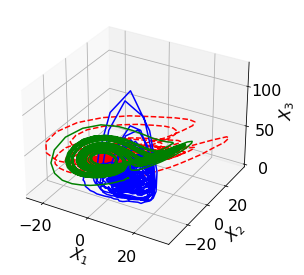

Run --- 2


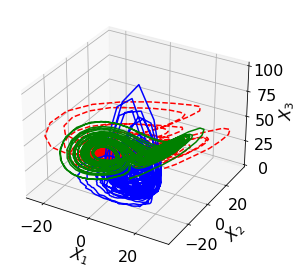

Run --- 3


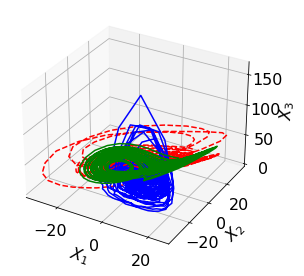

Run --- 4


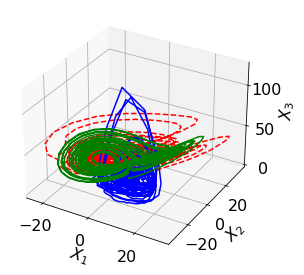

Run --- 5


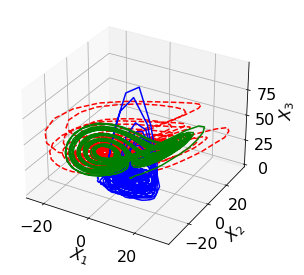

In [30]:
#fig = plt.figure()
for i in range(5):
    print("Run --- {}".format(i+1))
    x_lorenz, y_lorenz = lorenz_ssm.generate_single_sequence(T=2000, sigma_e2_dB=-20.0, smnr_dB=10.0)
    x_chen, y_chen = chen_ssm.generate_single_sequence(T=10000, sigma_e2_dB=-20.0, smnr_dB=10.0)
    x_rossler, y_rossler = rossler_ssm.generate_single_sequence(T=20000, sigma_e2_dB=-15.0, smnr_dB=10.0)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x_chen[:,0], x_chen[:,1], x_chen[:,2], 'r--')#, label=legend)
    ax.plot(x_rossler[:,0], x_rossler[:,1], x_rossler[:,2], 'b-')#, label=legend)
    ax.plot(x_lorenz[:,0], x_lorenz[:,1], x_lorenz[:,2], 'g-')#, label=legend)
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    ax.set_zlabel('$X_3$')
    #plt.legend()
    plt.tight_layout()
    #plot_3d_state_trajectory(fig, X=x_chen, legend='$\\mathbf{x}^{true}$', m='r--', savefig=False, savefig_name=None)
    #plot_3d_state_trajectory(fig, X=x_rossler, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    #plot_state_trajectory_axeswise(X=x_rossler, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    #plot_3d_measurment_trajectory(Y=y_rossler, legend='$\\mathbf{y}$', m='r-', savefig=False, savefig_name=None)
    plt.show()

Run --- 1


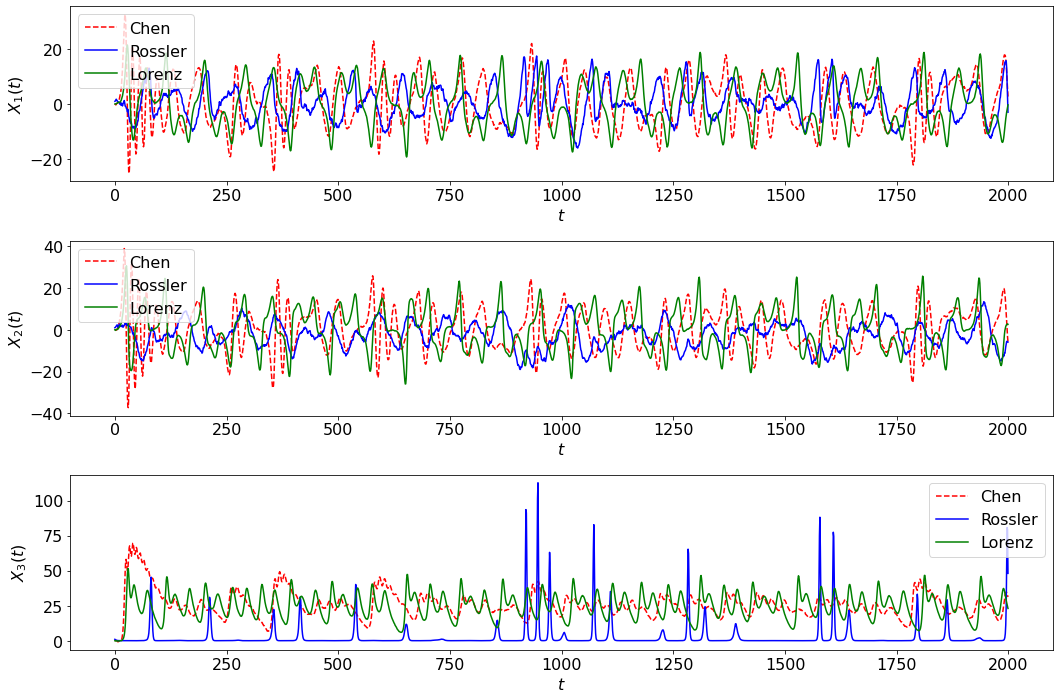

Run --- 2


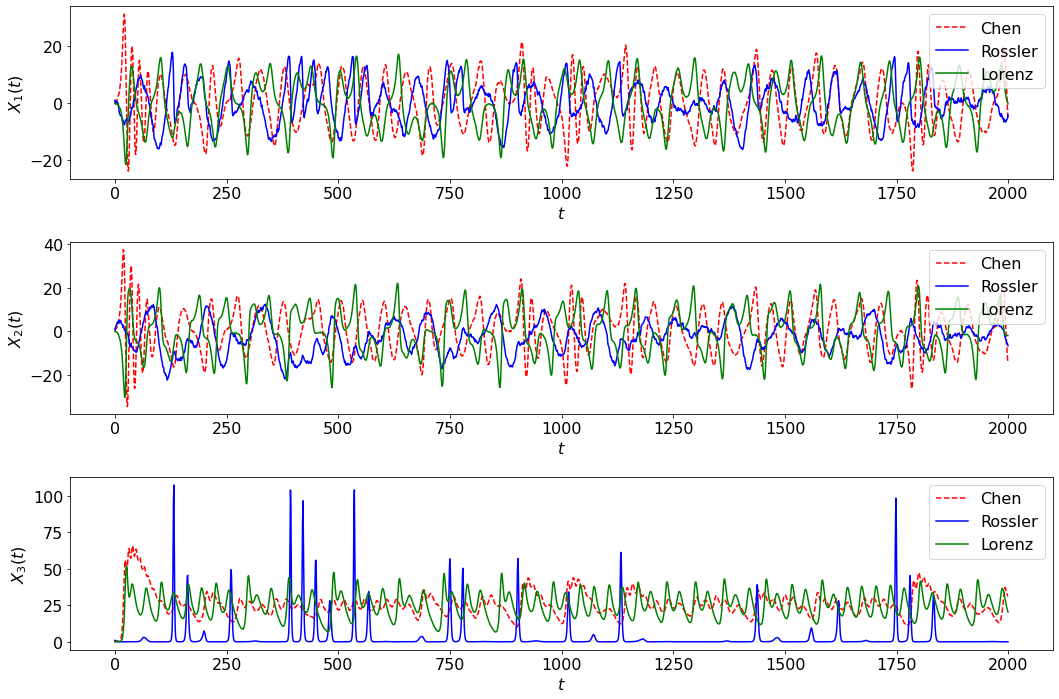

In [32]:
for i in range(2):
    print("Run --- {}".format(i+1))
    x_lorenz, y_lorenz = lorenz_ssm.generate_single_sequence(T=2000, sigma_e2_dB=-20.0, smnr_dB=10.0)
    x_chen, y_chen = chen_ssm.generate_single_sequence(T=10000, sigma_e2_dB=-20.0, smnr_dB=10.0)
    x_rossler, y_rossler = rossler_ssm.generate_single_sequence(T=20000, sigma_e2_dB=-15.0, smnr_dB=10.0)
    fig = plt.figure(figsize=(15,10))
    ax = fig.add_subplot(311)
    ax.plot(x_chen[:,0],'r--')#, label=legend)
    ax.plot(x_rossler[:,0], 'b-')#, label=legend)
    ax.plot(x_lorenz[:,0], 'g-')#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_1(t)$')
    #ax.legend(['Chen', 'Lorenz'])
    ax.legend(['Chen', 'Rossler', 'Lorenz'])
    
    ax = fig.add_subplot(312)
    ax.plot(x_chen[:,1],'r--')#, label=legend)
    ax.plot(x_rossler[:,1], 'b-')
    ax.plot(x_lorenz[:,1], 'g-')#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_2(t)$')
    #ax.legend(['Chen', 'Lorenz'])
    ax.legend(['Chen', 'Rossler', 'Lorenz'])
    
    ax = fig.add_subplot(313)
    ax.plot(x_chen[:,2],'r--')#, label=legend)
    ax.plot(x_rossler[:,2], 'b-')#, label=legend)
    ax.plot(x_lorenz[:,2], 'g-')#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_3(t)$')
    #ax.legend(['Chen', 'Lorenz'])
    ax.legend(['Chen', 'Rossler', 'Lorenz'])
    
    #ax.set_zlabel('$X_3$')
    #plt.legend()
    plt.tight_layout()
    #plot_3d_state_trajectory(fig, X=x_chen, legend='$\\mathbf{x}^{true}$', m='r--', savefig=False, savefig_name=None)
    #plot_3d_state_trajectory(fig, X=x_rossler, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    #plot_state_trajectory_axeswise(X=x_rossler, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    #plot_3d_measurment_trajectory(Y=y_rossler, legend='$\\mathbf{y}$', m='r-', savefig=False, savefig_name=None)
    plt.show()

Run --- 1


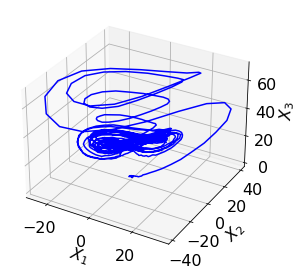

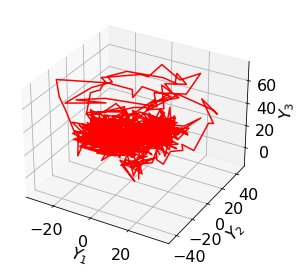

Run --- 2


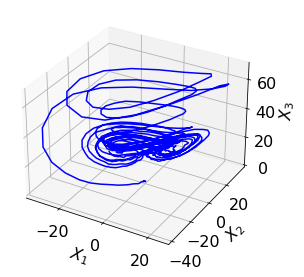

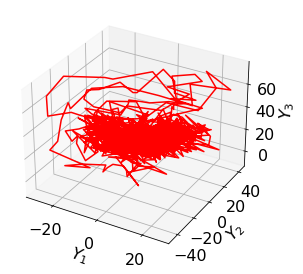

Run --- 3


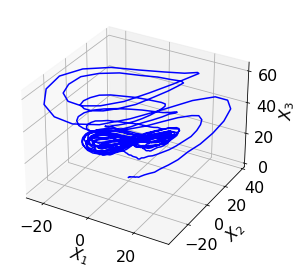

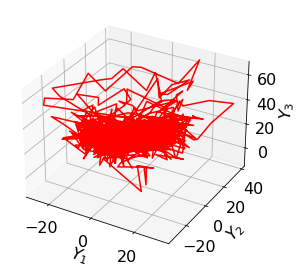

Run --- 4


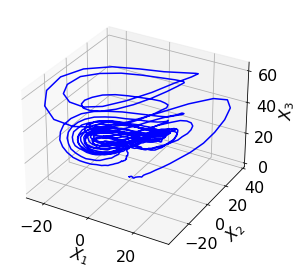

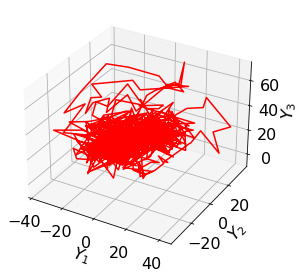

Run --- 5


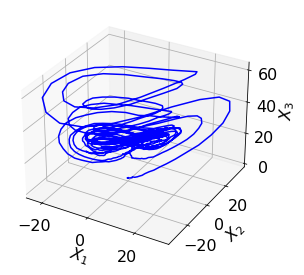

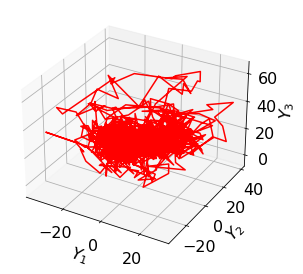

Run --- 6


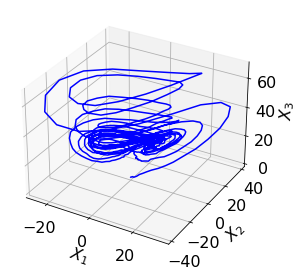

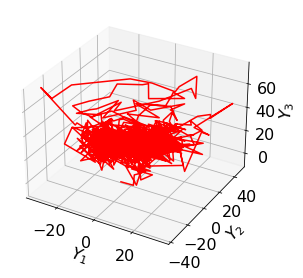

Run --- 7


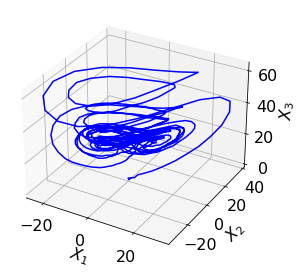

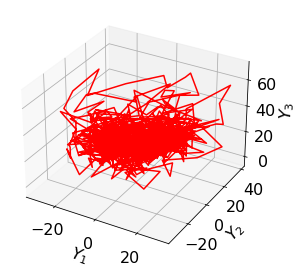

Run --- 8


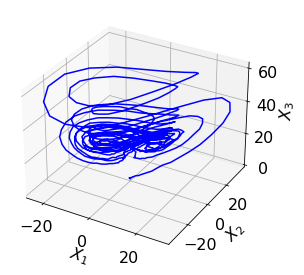

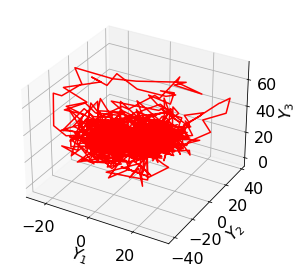

Run --- 9


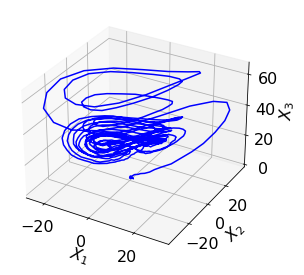

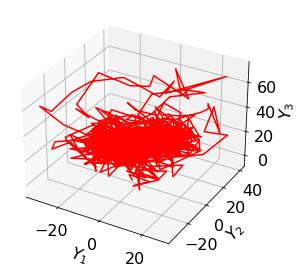

Run --- 10


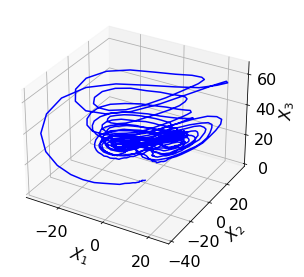

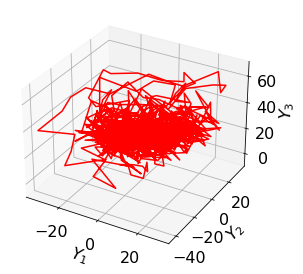

In [23]:
#fig = plt.figure()
for i in range(10):
    print("Run --- {}".format(i+1))
    x_chen, y_chen = chen_ssm.generate_single_sequence(T=5000, sigma_e2_dB=-20.0, smnr_dB=10.0)
    plot_3d_state_trajectory(X=x_chen, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    #plot_state_trajectory_axeswise(X=x_chen, legend='$\\mathbf{x}^{true}$', m='b-', savefig=False, savefig_name=None)
    plot_3d_measurment_trajectory(Y=y_chen, legend='$\\mathbf{y}$', m='r-', savefig=False, savefig_name=None)
    plt.show()